# Fundamentals of Data Science  
## Week 4: Data Preparation I (Cleaning, Encoding, Scaling)

---

## Table of Contents
1. Learning Objectives
2. Conceptual Foundation
3. Missing Data Imputation
4. Outliers Handling
5. Encoding
6. Scaling
7. Group Assignment 1: PM2.5 - Data Cleansing  

---

## 1) Learning Objectives

เมื่อจบคาบนี้ นักศึกษาจะสามารถ

1. เลือกและอธิบายวิธีจัดการ missing data และ outliers ที่เหมาะสมกับบริบทข้อมูล
2. เตรียมข้อมูลให้อยู่ในรูปแบบที่พร้อมสำหรับการทำ modeling (encoding, scaling)
3. อธิบายผลกระทบของการตัดสินใจในขั้น Data Preparation ต่อผลลัพธ์ของโมเดล

---

## 2) Conceptual Foundation

Data Preparation ประกอบด้วย 3 กลุ่มงานหลัก

1. **Cleaning**

   * Missing data
   * Outliers
   * Inconsistency / invalid values
2. **Encoding**

   * แปลงข้อมูลเชิงหมวดหมู่ → ตัวเลข
3. **Scaling**

   * ทำให้ feature อยู่ใน scale ที่เหมาะสม

> ในงาน Data Science จริง
>
> * 60–80% ของเวลาถูกใช้ไปกับ Data Preparation
> * โมเดลที่ “ดี” มักแพ้ข้อมูลที่ “เตรียมมาดี”

---

## 3) Missing Data Imputation

### Missing Data Imputation ≠ การ “อุดรู”

การทำ imputation คือ **การสร้างค่าทดแทนโดยมีสมมติฐานแฝงอยู่เสมอ**

| กลุ่ม        | สมมติฐานหลัก                        |
| ------------ | ----------------------------------- |
| Generalized  | ข้อมูลทั้งคอลัมน์ “คล้ายกันพอ”      |
| Similar case | กลุ่มย่อยมี pattern ต่างกัน         |
| Model-based  | ความสัมพันธ์เชิงตัวแปร “พอทำนายได้” |
| Time-series  | ค่าใกล้เคียงในเวลา “มีความหมาย”     |

> ❗ ไม่มีวิธีใด “ถูกที่สุด”  
> ✔ มีแต่วิธีที่ *เหมาะกับบริบทมากกว่า*

---

In [ ]:
# ใช้ไฟล์
# - AmesHousing.csv
# - PRSA_data_2010.1.1-2014.12.31.csv

from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving PRSA_data_2010.1.1-2014.12.31.csv to PRSA_data_2010.1.1-2014.12.31.csv
Saving AmesHousing.csv to AmesHousing.csv


dict_keys(['PRSA_data_2010.1.1-2014.12.31.csv', 'AmesHousing.csv'])

In [ ]:
import pandas as pd

housing_df = pd.read_csv("AmesHousing.csv")
housing_df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


* ดูชนิดข้อมูลก่อน
* ดูว่า missing กระจายอยู่ตรงไหน

In [ ]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [ ]:
housing_df.isna().mean().sort_values(ascending=False).head(10)

,0
Pool QC,0.995563
Misc Feature,0.963823
Alley,0.932423
Fence,0.804778
Mas Vnr Type,0.605802
Fireplace Qu,0.485324
Lot Frontage,0.167235
Garage Qual,0.054266
Garage Yr Blt,0.054266
Garage Cond,0.054266


* คอลัมน์ไหน missing เยอะ
* missing แบบนี้ “น่าจะเกิดจากอะไร”

### 3.1 Generalized Imputation

**แทนที่ด้วยค่ากลางของทั้งคอลัมน์**

ใช้เมื่อ:

* missing ratio ต่ำ–กลาง
* distribution ไม่ skew มาก
* ยังไม่รู้ structure ของข้อมูลดีพอ

**ตัวอย่างคอลัมน์**

* `LotFrontage` (numeric)
* missing กระจาย

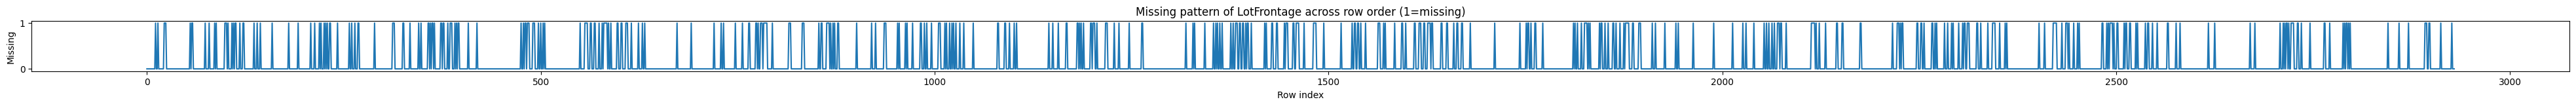

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(50, 1))
plt.plot(housing_df['Lot Frontage'].isna().astype(int))
plt.title("Missing pattern of LotFrontage across row order (1=missing)")
plt.xlabel("Row index")
plt.ylabel("Missing")
plt.show()

In [ ]:
housing_df['Lot Frontage by mean'] = housing_df['Lot Frontage'].fillna(
  housing_df['Lot Frontage'].mean()
)

In [ ]:
housing_df[['Lot Frontage', 'Lot Frontage by mean']].sample(10)

,Lot Frontage,Lot Frontage by mean
911,65.0,65.0
1485,67.0,67.0
1689,110.0,110.0
1389,94.0,94.0
2372,21.0,21.0
415,24.0,24.0
2159,65.0,65.0
989,87.0,87.0
2020,60.0,60.0
2144,80.0,80.0


ทดลองเทียบ:

* mean vs median
* ก่อน–หลัง imputation (distribution)

In [ ]:
housing_df[['Lot Frontage', 'Lot Frontage by mean']].describe()

,Lot Frontage,Lot Frontage by mean
count,2440.000000,2930.000000
mean,69.224590,69.224590
std,23.365335,21.321523
min,21.000000,21.000000
25%,58.000000,60.000000
50%,68.000000,69.224590
75%,80.000000,78.000000
max,313.000000,313.000000


* ทำง่าย
* เป็น baseline
* แต่ variance ลดลง

> “นี่คือวิธีที่ง่ายที่สุด แต่ไม่ใช่วิธีที่ดีที่สุดเสมอ”

### 3.2 Similar Case Imputation

**แทนที่ด้วยค่ากลางของแต่ละกลุ่ม**

ใช้เมื่อ:

* missing เป็น MAR
* กลุ่มย่อยมี behavior ต่างกัน
* domain knowledge บอกว่ากลุ่มสำคัญ

In [ ]:
housing_df['Neighborhood'].value_counts()

,count
Neighborhood,
NAmes,443
CollgCr,267
OldTown,239
Edwards,194
Somerst,182
NridgHt,166
Gilbert,165
Sawyer,151
NWAmes,131


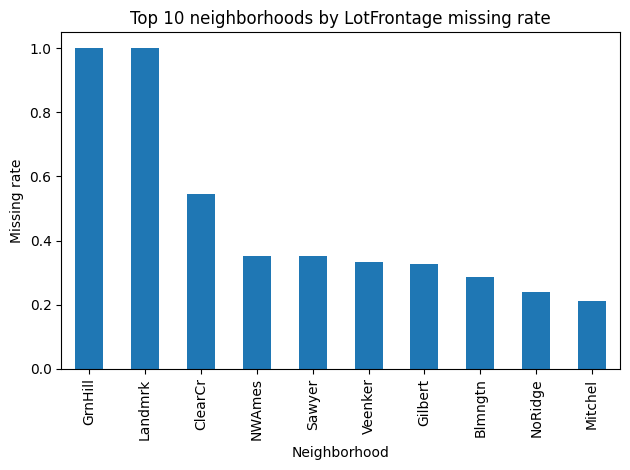

Max missing rate: 1.0
Median missing rate: 0.1527494356659142
Std missing rate: 0.25106410395906714


In [ ]:
# missing rate ต่อ Neighborhood
miss_rate_by_group = housing_df.groupby('Neighborhood')['Lot Frontage'].apply(lambda s: s.isna().mean())
miss_rate_by_group = miss_rate_by_group.sort_values(ascending=False)

# plot top groups
top_k = 10
plt.figure()
miss_rate_by_group.head(top_k).plot(kind="bar")
plt.title(f"Top {top_k} neighborhoods by LotFrontage missing rate")
plt.xlabel("Neighborhood")
plt.ylabel("Missing rate")
plt.tight_layout()
plt.show()

# เปรียบเทียบการกระจุก: max vs median
print("Max missing rate:", float(miss_rate_by_group.max()))
print("Median missing rate:", float(miss_rate_by_group.median()))
print("Std missing rate:", float(miss_rate_by_group.std()))

In [ ]:
housing_df['Lot Frontage by group'] = housing_df.groupby(
    'Neighborhood'
)['Lot Frontage'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
housing_df[['Lot Frontage', 'Lot Frontage by group', 'Neighborhood']].sample(10)

,Lot Frontage,Lot Frontage by group,Neighborhood
1245,60.0,60.0,NAmes
1690,107.0,107.0,NridgHt
1197,87.0,87.0,NWAmes
170,55.0,55.0,OldTown
1275,59.0,59.0,NAmes
836,65.0,65.0,CollgCr
183,60.0,60.0,OldTown
38,83.0,83.0,NridgHt
956,150.0,150.0,Timber
212,65.0,65.0,SWISU


เปรียบเทียบ

| วิธี            | สิ่งที่รักษาได้        |
| ------------- | ---------------- |
| Global median | ภาพรวม           |
| Group median  | structure ของกลุ่ม |

<br>

> คำถาม:
>
> * ถ้าแบ่งกลุ่มผิด จะเกิดอะไรขึ้น
> * กลุ่มเล็กเกินไปควรทำหรือไม่

---

### 3.3 Model-based Imputation

**ใช้โมเดลทำนายค่าที่หาย**

ใช้เมื่อ:

* feature อื่นสัมพันธ์กับค่าที่หาย
* ยอมรับความซับซ้อนเพิ่ม
* dataset ใหญ่พอ

> ⚠ เสี่ยงเรื่อง leakage ถ้าใช้ไม่ถูกจังหวะ

In [ ]:
from sklearn.linear_model import LinearRegression

features = ['Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built']

train = housing_df[housing_df['Lot Frontage'].notna()]
test  = housing_df[housing_df['Lot Frontage'].isna()]

X_train = train[features]
y_train = train['Lot Frontage']
X_test  = test[features]

model = LinearRegression()
model.fit(X_train, y_train)

housing_df['Lot Frontage by model'] = housing_df['Lot Frontage']
housing_df.loc[housing_df['Lot Frontage'].isna(), 'Lot Frontage by model'] = model.predict(X_test)

In [ ]:
housing_df[['Lot Frontage', 'Lot Frontage by model']].sample(10)

,Lot Frontage,Lot Frontage by model
2204,53.0,53.0
666,81.0,81.0
1917,65.0,65.0
1967,80.0,80.0
2799,90.0,90.0
2528,80.0,80.0
279,94.0,94.0
840,112.0,112.0
2863,81.0,81.0
2412,65.0,65.0


**ข้อควรระวัง**

* ค่าที่ได้ “ดูดี” แต่คือค่าที่โมเดลคิด
* uncertainty ถูกซ่อนไว้
* ถ้าใช้ใน train set อาจ optimistic

---

### 3.4 Time-series Imputation

**ใช้โครงสร้างของเวลา**

ใช้เมื่อ:

* ข้อมูลมีลำดับเวลา
* ค่าใกล้เคียงในเวลา “มีความหมาย”
* sensor-based data

In [ ]:
import pandas as pd

air_df = pd.read_csv("PRSA_data_2010.1.1-2014.12.31.csv")
air_df['date'] = air_df['year'].astype(str) + '-' + air_df['month'].astype(str) + '-' + air_df['day'].astype(str)
air_df['date'] = pd.to_datetime(air_df['date'])
air_df.set_index('date', inplace=True)
air_df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
date,,,,,,,,,,,,,
2010-01-01,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
2014-12-31,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
2014-12-31,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0


In [ ]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43824 entries, 2010-01-01 to 2014-12-31
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.7+ MB


In [ ]:
air_df = air_df.sort_index()

air_df['pm2.5_ffill'] = air_df['pm2.5'].ffill()
air_df['pm2.5_bfill'] = air_df['pm2.5'].bfill()
air_df['pm2.5_interp'] = air_df['pm2.5'].interpolate()

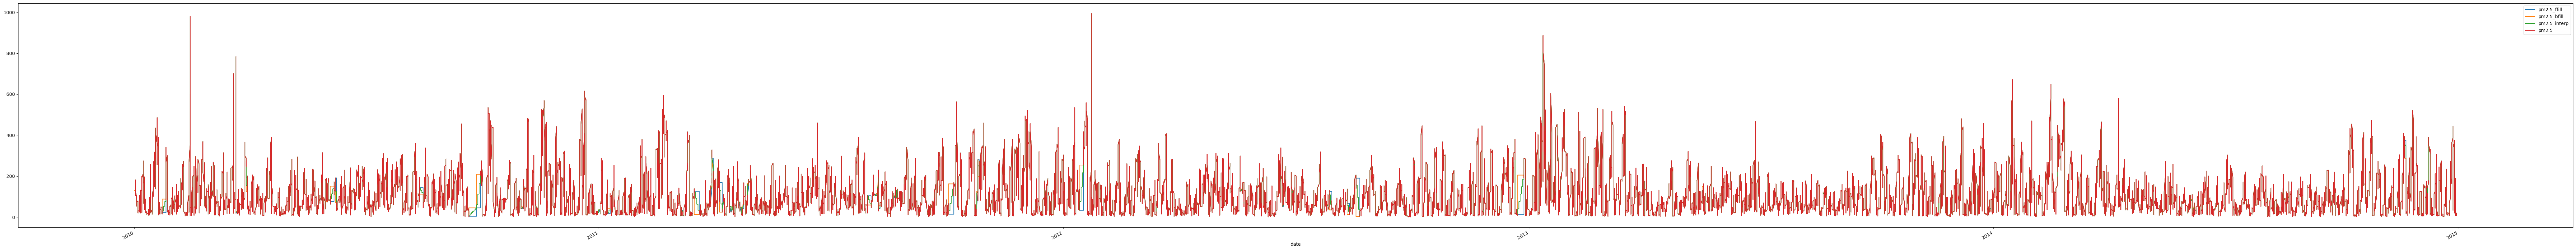

In [ ]:
air_df[['pm2.5_ffill', 'pm2.5_bfill', 'pm2.5_interp', 'pm2.5']].plot(figsize=(100, 10))
plt.show()

**Discussion**

* ffill / bfill / interpolate ต่างกันอย่างไร

---

## 4) Outliers Handling

### 4.1 Outliers — ไม่ใช่ทุกค่าผิดคือขยะ

| ประเภท         | ตัวอย่าง        | ควรทำอย่างไร        |
| -------------- | --------------- | ------------------- |
| Error          | PM2.5 = -10     | remove / correct    |
| Rare but valid | PM2.5 ช่วงวิกฤต | keep / cap          |
| Structural     | seasonal spike  | feature engineering |

---

### 4.2 ทำไม Outliers ถึงสำคัญใน Data Preparation

* Outliers ทำให้

  * ค่าเฉลี่ยเพี้ยน
  * scaling เพี้ยน
  * model บางแบบพังทันที
* แต่การลบ outliers ผิดบริบท

  * ทำให้รายงานบิดเบือน
  * โดยเฉพาะข้อมูลสิ่งแวดล้อม / สาธารณสุข

> **Outliers คือจุดตัดของสถิติ + domain + ethics**

---

### 4.3 แนวทางจัดการ Outliers

In [ ]:
Q1 = housing_df['Gr Liv Area'].quantile(0.25)
Q3 = housing_df['Gr Liv Area'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = housing_df[(housing_df['Gr Liv Area'] < lower) | (housing_df['Gr Liv Area'] > upper)]

In [ ]:
housing_df['Gr Liv Area'].describe()

,Gr Liv Area
count,2930.000000
mean,1499.690444
std,505.508887
min,334.000000
25%,1126.000000
50%,1442.000000
75%,1742.750000
max,5642.000000


In [ ]:
outliers['Gr Liv Area'].describe()

,Gr Liv Area
count,75.000000
mean,3067.973333
std,565.424523
min,2668.000000
25%,2739.000000
50%,2826.000000
75%,3167.000000
max,5642.000000


* บ้านหลังใหญ่มาก = ผิด หรือ แค่รวยมาก?

* ถ้าลบทิ้ง จะกระทบภาพรวมตลาดหรือไม่

#### วิธีที่ 1: Keep (ไม่ทำอะไร)

เหมาะเมื่อ:

* ค่า extreme มีความหมายจริง
* เป็นข้อมูล domain-critical

---


#### วิธีที่ 2: Cap / Winsorize

ใช้เมื่อ:

* ไม่อยากลบข้อมูล
* แต่ไม่อยากให้ค่า extreme ครอบงำ model

---

In [ ]:
housing_df['Gr Liv Area capped'] = housing_df['Gr Liv Area'].clip(lower, upper)
housing_df[['Gr Liv Area', 'Gr Liv Area capped']].describe()

,Gr Liv Area,Gr Liv Area capped
count,2930.000000,2930.000000
mean,1499.690444,1489.449019
std,505.508887,468.318486
min,334.000000,334.000000
25%,1126.000000,1126.000000
50%,1442.000000,1442.000000
75%,1742.750000,1742.750000
max,5642.000000,2667.875000


#### วิธีที่ 3: Remove (ระวังมาก)

ใช้เมื่อ:

* เป็น error ชัดเจน
* มีเหตุผลอธิบายได้ในรายงาน

> ❗ ต้องพูดชัด
> “ลบเพราะอะไร ไม่ใช่ลบเพราะกราฟไม่สวย”

---

In [ ]:
housing_df_removed = housing_df[(housing_df['Gr Liv Area'] >= lower) & (housing_df['Gr Liv Area'] <= upper)]
housing_df_removed['Gr Liv Area'].describe()

,Gr Liv Area
count,2855.000000
mean,1458.492119
std,433.167276
min,334.000000
25%,1117.500000
50%,1430.000000
75%,1718.500000
max,2656.000000


### 4.4 Outliers in Time-series

ลักษณะ Outliers ใน Time-series:

* spike
* sudden drop
* flatline จาก sensor ค้าง

```python
df_ts['pm25'].plot()
```

---

## 5) Encoding

### 5.1 ปัญหาที่แท้จริงของข้อมูลเชิงหมวดหมู่

ในโลกจริง ข้อมูลจำนวนมากเป็นแบบนี้:

* ประเภทสถานี (`station_type`)
* ทิศทางลม (`N, NE, E, ...`)
* ฤดูกาล (`Hot, Rainy, Cool`)
* ระดับ (`Low, Medium, High`)

**คำถามสำคัญไม่ใช่ “จะแปลงยังไง” แต่คือ**

> “โมเดลจะ *ตีความ* ตัวเลขที่เราใส่เข้าไปอย่างไร”

---

### 5.2 ทำไมเราไม่ใส่ตัวเลขตรง ๆ

ตัวอย่าง:

```text
Low = 1
Medium = 2
High = 3
```

สิ่งที่ *โมเดลเข้าใจทันที* คือ:

* High > Medium > Low
* ระยะห่าง 3–2 = 2–1

❗ แต่ในความจริง:

* “Medium” ไม่ได้หมายความว่ามากกว่า “Low” เป็น 2 เท่า

> **Encoding = การสื่อสารความหมายให้โมเดลเข้าใจ**
> ไม่ใช่แค่แปลงชนิดข้อมูล

---

### 5.3 ประเภทของ Encoding

#### (1) Label Encoding

**การแทนแต่ละ category ด้วยเลขจำนวนเต็ม โดยไม่ได้รับประกันความหมายของลำดับ**

เช่น:

```
Bangkok = 0  
ChiangMai = 1  
Phuket = 2
```

ลักษณะสำคัญ:

* ตัวเลขเป็น **รหัส (ID)** ไม่ใช่ระดับ
* ถ้าเอาไปใช้กับโมเดลที่ตีความ “ขนาดของตัวเลข”
  → **ผิดทันที**

---

#### (2) Ordinal Encoding

**แปลง category → ตัวเลขที่มีลำดับความหมาย**

เหมาะเมื่อ:

* หมวดหมู่มีลำดับเชิงความหมายจริง (true ordinal)
* ระยะห่างระหว่างระดับ “พอรับได้” สำหรับโมเดล

ตัวอย่าง:

* AQI Level:
  `Good < Moderate < Unhealthy < Very Unhealthy`
* Rating:
  `Poor < Fair < Good < Excellent`

การเข้ารหัส (ตัวอย่างหนึ่ง):

```
Good = 1  
Moderate = 2  
Unhealthy = 3  
Very Unhealthy = 4
```

ข้อควรระวัง:

* ตัวเลข **สื่อความหมาย “ลำดับ” เท่านั้น**
* ไม่ได้สื่อว่า `Unhealthy` แย่กว่า `Moderate` เป็น “สองเท่า”

| Encoder        | ใช้เมื่อ        | ความเสี่ยง               |
| -------------- | --------------- | ------------------------ |
| LabelEncoder   | class label (y) | ใช้กับ feature แล้วพัง   |
| OrdinalEncoder | ordinal feature | ต้องมั่นใจว่ามีลำดับจริง |

---

In [ ]:
housing_df['Overall Qual'].value_counts()

,count
Overall Qual,
5,825
6,732
7,602
8,350
4,226
9,107
3,40
10,31
2,13


#### (3) One-Hot Encoding

**แยก category เป็นหลายคอลัมน์**

เหมาะเมื่อ:

* ไม่มีลำดับ
* category เป็นแค่ “ชื่อ”

ตัวอย่าง:

* Station type
* Wind direction
* เขตพื้นที่

ข้อดี:

* โมเดลไม่ตีความผิดเชิงลำดับ

ข้อเสีย:

* จำนวน feature เพิ่ม
* sparse data

---

In [ ]:
housing_df[['Neighborhood']].nunique()

,0
Neighborhood,28


In [ ]:
housing_df_encoded = pd.get_dummies(housing_df[['Neighborhood']])
housing_df_encoded.shape

(2930, 28)

In [ ]:
housing_df_encoded.sample(10)

,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
2120,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2551,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
168,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2863,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1673,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1991,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
172,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
893,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1611,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1312,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


* feature เพิ่ม
* แต่ไม่สร้างลำดับปลอม

#### ข้อควรระวัง

> Encoding ที่ “ผิด”
> ทำให้โมเดล **มั่นใจผิดทิศทาง** โดยที่เราไม่รู้ตัว

---

## 6) Scaling

### 6.1 ปัญหาที่ซ่อนอยู่ในตัวเลข

พิจารณา feature สองตัว:

* PM2.5: ช่วง 0–300
* Wind speed: ช่วง 0–10

ถ้า **ไม่ scale**:

* โมเดลจะ “สนใจ PM2.5 มากกว่า” โดยอัตโนมัติ
* ไม่ใช่เพราะสำคัญกว่า แต่เพราะตัวเลขใหญ่กว่า

> โมเดลหลายแบบ “วัดระยะ”
> และระยะ = ตัวเลข

---

### 6.2 Scaling in Data Science

Scaling คือ:

* การปรับช่วงค่า
* โดย **ไม่เปลี่ยนความสัมพันธ์เชิงข้อมูล**

ไม่ใช่:

* การแก้ skew (นั่นคือ transformation)

---

### 6.3 Scaling Methods

In [ ]:
from sklearn.model_selection import train_test_split

features = ['Lot Area', 'Gr Liv Area', 'Overall Qual', 'Year Built']
summary = housing_df[features].describe().T
summary['range'] = summary['max'] - summary['min']
summary.sort_values('range', ascending=False)

,count,mean,std,min,25%,50%,75%,max,range
Lot Area,2930.0,10147.921843,7880.017759,1300.0,7440.25,9436.5,11555.25,215245.0,213945.0
Gr Liv Area,2930.0,1499.690444,505.508887,334.0,1126.00,1442.0,1742.75,5642.0,5308.0
Year Built,2930.0,1971.356314,30.245361,1872.0,1954.00,1973.0,2001.00,2010.0,138.0
Overall Qual,2930.0,6.094881,1.411026,1.0,5.00,6.0,7.00,10.0,9.0


In [ ]:
X_train, X_test = train_test_split(housing_df[features], test_size=0.2, random_state=555)

#### (1) Min–Max Scaling

ทำให้ข้อมูลอยู่ในช่วง 0–1

เหมาะเมื่อ:

* distribution ค่อนข้างปกติ
* ไม่มี outlier รุนแรง

ข้อควรระวัง:

* outlier 1 จุด → ดึงทั้งช่วง

---

In [ ]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()
mm_scaler.fit_transform(X_train)

array([[0.06300685, 0.27908309, 0.88888889, 0.96376812],
       [0.03052186, 0.14765998, 0.44444444, 0.71014493],
       [0.05527121, 0.26666667, 0.44444444, 0.61594203],
       ...,
       [0.06131482, 0.2947469 , 0.88888889, 0.97826087],
       [0.0316156 , 0.2078319 , 0.55555556, 0.55072464],
       [0.03453224, 0.23094556, 0.66666667, 0.96376812]])

In [ ]:
X_train_mm = pd.DataFrame(mm_scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_train_mm

,Lot Area,Gr Liv Area,Overall Qual,Year Built
2384,0.063007,0.279083,0.888889,0.963768
395,0.030522,0.147660,0.444444,0.710145
2720,0.055271,0.266667,0.444444,0.615942
390,0.041319,0.180134,0.555556,0.739130
1876,0.042015,0.127221,0.444444,0.673913
...,...,...,...,...
2598,0.044937,0.058835,0.222222,0.413043
2628,0.031059,0.141929,0.444444,0.630435
1057,0.061315,0.294747,0.888889,0.978261
686,0.031616,0.207832,0.555556,0.550725


* เปรียบเทียบก่อน–หลัง scaling

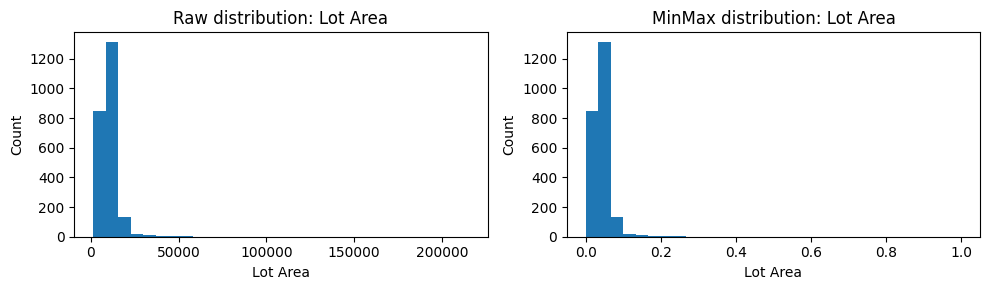

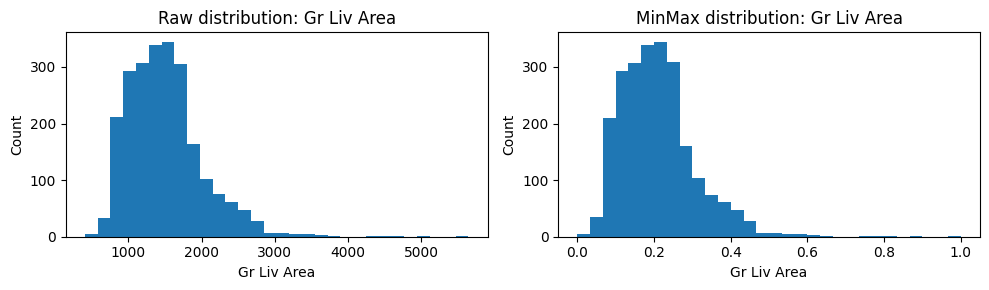

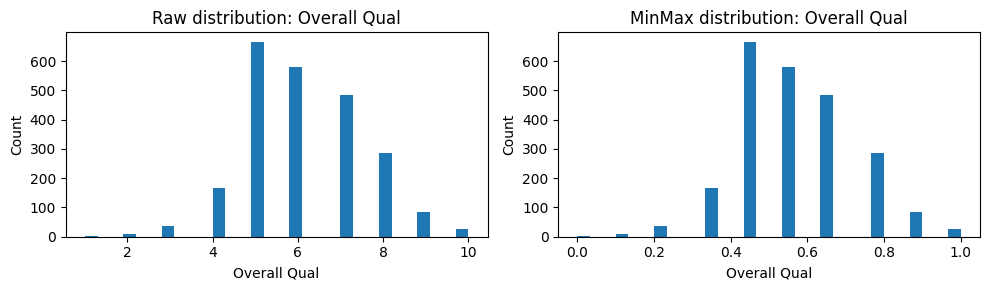

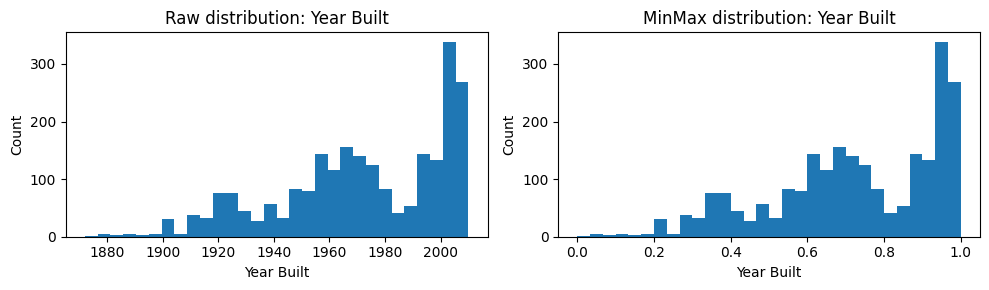

In [ ]:
for col in features:
  plt.figure(figsize=(10, 3))
  plt.subplot(1, 2, 1)
  plt.hist(X_train[col].dropna(), bins=30)
  plt.title(f"Raw distribution: {col}")
  plt.xlabel(col)
  plt.ylabel("Count")

  plt.subplot(1, 2, 2)
  plt.hist(X_train_mm[col].dropna(), bins=30)
  plt.title(f"MinMax distribution: {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [ ]:
X_test_mm  = pd.DataFrame(mm_scaler.transform(X_test), columns=features, index=X_test.index)
X_test_mm

,Lot Area,Gr Liv Area,Overall Qual,Year Built
2844,0.047152,0.165425,0.333333,0.275362
303,0.036645,0.133715,0.555556,0.355072
838,0.043782,0.239542,0.666667,0.898551
2400,0.089420,0.443362,0.888889,0.963768
2586,0.029914,0.140974,0.444444,0.608696
...,...,...,...,...
2751,0.028923,0.153009,0.666667,0.963768
631,0.033186,0.204585,0.555556,0.615942
227,0.048218,0.187011,0.555556,0.768116
2498,0.060904,0.427698,0.666667,0.739130


#### (2) Standardization (Z-score)

ทำให้:

* mean = 0
* std = 1

เหมาะเมื่อ:

* ใช้กับ model ที่อิง distance
* มี outlier บ้าง แต่ไม่รุนแรงมาก

---

In [ ]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train_std = pd.DataFrame(std_scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_train_std

,Lot Area,Gr Liv Area,Overall Qual,Year Built
2384,0.584591,0.709122,2.036417,1.095678
395,-0.302084,-0.631069,-0.784718,-0.059342
2720,0.373448,0.582505,-0.784718,-0.488349
390,-0.007376,-0.299917,-0.079435,0.072660
1876,0.011633,-0.839500,-0.784718,-0.224345
...,...,...,...,...
2598,0.091370,-1.536867,-2.195286,-1.412365
2628,-0.287412,-0.689508,-0.784718,-0.422348
1057,0.538408,0.868854,2.036417,1.161679
686,-0.272231,-0.017464,-0.079435,-0.785354


In [ ]:
X_train_std.describe().loc[["mean","std"]]

,Lot Area,Gr Liv Area,Overall Qual,Year Built
mean,-6.972049e-17,-1.333783e-16,-6.668916e-17,-3.234424e-15
std,1.000213e+00,1.000213e+00,1.000213e+00,1.000213e+00


* เปรียบเทียบก่อน–หลัง scaling

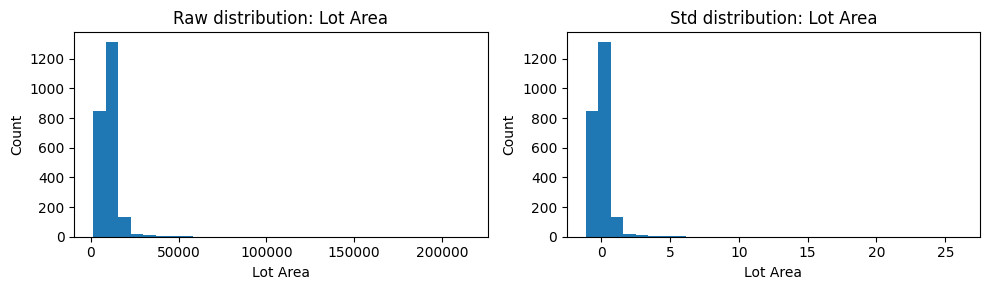

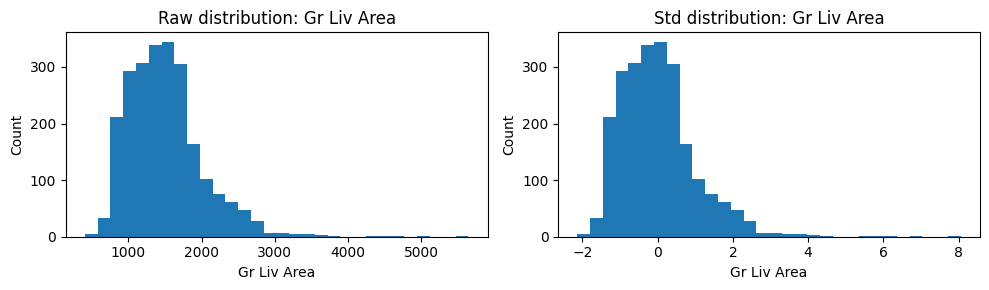

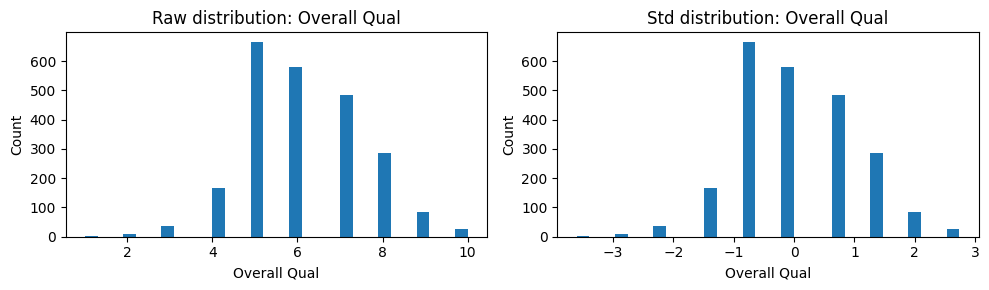

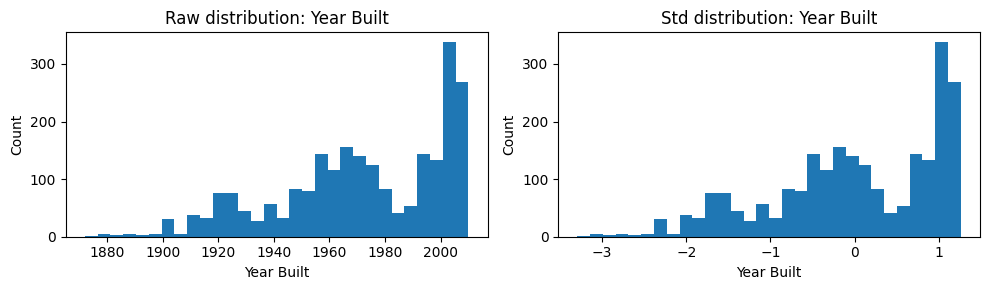

In [ ]:
for col in features:
  plt.figure(figsize=(10, 3))
  plt.subplot(1, 2, 1)
  plt.hist(X_train[col].dropna(), bins=30)
  plt.title(f"Raw distribution: {col}")
  plt.xlabel(col)
  plt.ylabel("Count")

  plt.subplot(1, 2, 2)
  plt.hist(X_train_std[col].dropna(), bins=30)
  plt.title(f"Std distribution: {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

In [ ]:
X_test_std  = pd.DataFrame(std_scaler.transform(X_test), columns=features, index=X_test.index)
X_test_std

,Lot Area,Gr Liv Area,Overall Qual,Year Built
2844,0.151843,-0.449910,-1.490002,-2.039376
303,-0.134955,-0.773270,-0.079435,-1.676370
838,0.059858,0.305896,0.625849,0.798673
2400,1.305541,2.384361,2.036417,1.095678
2586,-0.318669,-0.699248,-0.784718,-0.521350
...,...,...,...,...
2751,-0.345716,-0.576527,0.625849,1.095678
631,-0.229364,-0.050579,-0.079435,-0.488349
227,0.180931,-0.229791,-0.079435,0.204663
2498,0.527181,2.224629,0.625849,0.072660


* ผลต่อระยะทาง

In [ ]:
import numpy as np

def euclid(a, b):
  a = np.asarray(a); b = np.asarray(b)
  return float(np.sqrt(((a - b) ** 2).sum()))

i, j, k = X_train.sample(3, random_state=555).index
raw_dist = [
  euclid(X_train.loc[i, features], X_train.loc[j, features]),
  euclid(X_train.loc[j, features], X_train.loc[k, features]),
  euclid(X_train.loc[i, features], X_train.loc[k, features])
]

std_dist = [
  euclid(X_train_std.loc[i, features], X_train_std.loc[j, features]),
  euclid(X_train_std.loc[j, features], X_train_std.loc[k, features]),
  euclid(X_train_std.loc[i, features], X_train_std.loc[k, features])
]

mm_dist  = [
  euclid(X_train_mm.loc[i, features], X_train_mm.loc[j, features]),
  euclid(X_train_mm.loc[j, features], X_train_mm.loc[k, features]),
  euclid(X_train_mm.loc[i, features], X_train_mm.loc[k, features])
]

pd.DataFrame({
  "raw": raw_dist,
  "std": std_dist,
  "mm": mm_dist
}, index=["i-j", "j-k", "i-k"])

,raw,std,mm
i-j,5030.166796,0.804475,0.053538
j-k,2689.323335,1.060050,0.134535
i-k,2383.229322,0.708882,0.116326


### 6.4 Scaling ไม่จำเป็นเสมอไป

โมเดลที่ **ไม่จำเป็นต้อง scale**

* Decision Tree
* Random Forest
* Tree-based model ทั้งหมด

โมเดลที่ **ควร scale เสมอ**

* KNN
* K-Means
* SVM
* Linear / Logistic Regression

> Scaling เป็นไปตาม *เงื่อนไขของโมเดล*

---

### 6.5 ข้อควรระวัง

* scale ก่อน split → data leakage
* scale target variable โดยไม่ตั้งใจ
* scale categorical ที่ encode ผิด

---

## 7) Group Assignment 1: PM2.5 - Data Cleansing

### เป้าหมาย

1. รวมข้อมูลหลายปีให้เป็น time-series เดียว แล้วทำ Data Cleansing

**Dataset:** PM2.5 (2021–2024)  
- `pm2.52021.csv`  
- `pm2.52022.csv`  
- `pm2.52023.csv`  
- `pm2.52024.csv`

โครงสร้าง (ทุกไฟล์เหมือนกัน):
- `Date` : วันที่
- คอลัมน์สถานีวัด (station codes) เช่น `54T`, `03T`, `A13`, …

2. ระบุประเภท missing data ที่พบ
3. กำหนดกติกาการจัดการแต่ละประเภท
4. เขียนโค้ดให้ทำงานได้จริง และอธิบายเหตุผล

### Deliverables

1. Notebook (หรือ .py) ที่มี:

* การสำรวจ missing patterns
* การตัดสินใจ + เหตุผล (markdown)
* โค้ดทำความสะอาด (pipeline-style)

2. ไฟล์ผลลัพธ์:

* `pm25_model_ready.csv` (ไม่มี NaN ใน features ที่ใช้)
* `station_quality_report.csv` (รายงานคุณภาพรายสถานี)
  * station
  * total missing days
  * missing ratio
  * first valid date
  * last valid date
  * longest missing run “ภายในช่วงที่สถานีมีข้อมูล” (internal longest gap)

> Hint: “internal gap” ต้องตัด leading/trailing NaN ก่อน
